# TASK 10. CHUNKING STRATEGY LAB

## Objective

This experiment evaluates the impact of different chunk sizes on retrieval performance.

Three chunking strategies are compared:

- Small Chunks
- Medium Chunks
- Large Chunks

The retrieval quality is measured using the same set of questions.

## Notebook Structure :

1. Objective
2. Install Libraries
3. Import Libraries
4. Load API Key
5. Load Documents
6. Chunk Strategy 1 (Small Chunks)
7. Chunk Strategy 2 (Medium Chunks)
8. Chunk Strategy 3 (Large Chunks)
9. Create Vector Databases
10. Create Test Questions
11. Compare Retrieval Results
12. Compare Number of Chunks
13. Visualize Chunk Distribution
14. Analysis
15. Conclusion

## Step 1: Install Required Libraries

This project requires several libraries for building the RAG pipeline.

The following libraries are installed:

- LangChain for RAG workflow orchestration.
- LangChain OpenAI for OpenAI integrations.
- LangChain Community for document loaders and vector stores.
- ChromaDB for vector database storage.
- Gradio for building the chatbot interface.
- Python-dotenv for loading API keys securely.

In [1]:
!pip install langchain
!pip install langchain-openai
!pip install langchain-community
!pip install chromadb
!pip install gradio
!pip install python-dotenv


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



## Step 2: Import Libraries

The required modules are imported to perform the following tasks:

- Load environment variables.
- Read and process documents.
- Split documents into chunks.
- Generate embeddings.
- Create the vector database.
- Build the retrieval chain.
- Develop the chatbot interface.

These libraries form the foundation of the Retrieval-Augmented Generation pipeline.

In [2]:
import os
from dotenv import load_dotenv

from langchain_community.document_loaders import TextLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI

from langchain_community.vectorstores import Chroma


from langchain_classic.chains import RetrievalQA

import gradio as gr

C:\Users\tfd570\AppData\Local\Temp\ipykernel_25780\693998462.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader
c:\Users\tfd570\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 3: Load OpenAI API Key

In [3]:
from openai import OpenAI  

load_dotenv()

# Get the OpenAI API keys from environment variables
openai_api_key = os.getenv("API_KEY")

# Let's configure the OpenAI Client using our key
openai_client = OpenAI(api_key=openai_api_key)
print("OpenAI client successfully configured.")

OpenAI client successfully configured.


## Step 4: Load Restaurant Documents

The restaurant dataset is loaded using LangChain's TextLoader.

The file contains information about Eleven Madison Park, including:

- Restaurant details
- Chef information
- Menu and dining experience
- Restaurant philosophy

The loaded document serves as the external knowledge source for the RAG system.

In [4]:

# Define the path to your data file
# Ensure 'eleven_madison_park_data.txt' is in the same folder as this notebook
DATA_FILE_PATH = "eleven_madison_park_data.txt"
print(f"Data file path set to: {DATA_FILE_PATH}")
# Let's load Eleven Madison Park Restaurant data, which has been scraped from their website
# The data is saved in "eleven_madison_park_data.txt", Langchain's TextLoader makes this easy to read
print(f"Attempting to load data from: {DATA_FILE_PATH}")

Data file path set to: eleven_madison_park_data.txt
Attempting to load data from: eleven_madison_park_data.txt


In [5]:


# Initialize the TextLoader with the file path and specify UTF-8 encoding
# Encoding helps handle various characters correctly
loader = TextLoader(DATA_FILE_PATH, encoding = "utf-8")

# Load the document(s) using TextLoader from LangChain, which loads the entire file as one Document object
raw_documents = loader.load()
print(f"Successfully loaded {len(raw_documents)} document(s).")

# Let's display a few characters of the loaded content to perform a sanity check!
print(raw_documents[0].page_content[:500] + "...")

Successfully loaded 1 document(s).
Source: https://www.elevenmadisonpark.com/
Title: Eleven Madison Park
Content:
Book on Resy
---END OF SOURCE---

Source: https://www.elevenmadisonpark.com/careers
Title: Careers — Eleven Madison Park
Content:
Join Our Team Eleven Madison Park ▾ All Businesses Eleven Madison Park Clemente Bar Daniel Humm Hospitality Filter Categories Culinary Pastry Wine & Beverage Dining Room Office & Admin Other Job Types Full Time Part Time Compensation Salary Hourly Apply filters OPEN OPPORTUNITIES Staff Acco...


## Step 5: Chunk Strategy 1 (Small Chunks)

In [7]:
small_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

small_docs = small_splitter.split_documents(
    raw_documents
)

print("Small chunks:", len(small_docs))

Small chunks: 74


## Step 6: Chunk Strategy 2 (Medium Chunks)

In [8]:
medium_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150
)

medium_docs = medium_splitter.split_documents(
    raw_documents
)

print("Medium chunks:", len(medium_docs))

Medium chunks: 38


## Step 7: Chunk Strategy 3 (Large Chunks)

In [9]:
large_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=200
)

large_docs = large_splitter.split_documents(
    raw_documents
)

print("Large chunks:", len(large_docs))

Large chunks: 23


## Step 8: Create Vector Databases

In [18]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=openai_api_key
)

small_db = Chroma.from_documents(
    documents=small_docs,
    embedding=embeddings
)

medium_db = Chroma.from_documents(
    documents=medium_docs,
    embedding=embeddings
)

large_db = Chroma.from_documents(
    documents=large_docs,
    embedding=embeddings
)

print("All vector databases created successfully.")

All vector databases created successfully.


## Step 9: Create Test Questions

In [10]:
questions = [
    "Who is Daniel Humm?",
    "What type of restaurant is Eleven Madison Park?",
    "What cuisine is served?",
    "What is the restaurant philosophy?",
    "Where is the restaurant located?",
    "What makes the restaurant unique?",
    "What ingredients are used?",
    "What dining experience is offered?",
    "Who owns the restaurant?",
    "What is the menu style?",
    "What is the history of the restaurant?",
    "How is sustainability emphasized?",
    "What beverages are served?",
    "What is the chef known for?",
    "How are dishes prepared?",
    "What values guide the restaurant?",
    "What is the customer experience?",
    "What awards has the restaurant received?",
    "What makes the menu special?",
    "Why is the restaurant famous?"
]

## Step 10: Compare Retrieval Results

In [19]:
retriever = small_db.as_retriever()

for question in questions[:5]:

    docs = retriever.invoke(question)

    print("\nQuestion:", question)
    print(docs[0].page_content[:200])


Question: Who is Daniel Humm?
Daniel Humm is a chef, author, speaker, and owner of Daniel Humm Hospitality , the New York-based hospitality group behind the highly acclaimed Eleven Madison Park, Clemente Bar , and direct-to-consum

Question: What type of restaurant is Eleven Madison Park?
Source: https://www.elevenmadisonpark.com/ourrestaurant
Title: About — Eleven Madison Park
Content:

Question: What cuisine is served?
comes to both technique and flavor. Mattia Rancati, Senior Sous Chef Stefano Casale , Senior Sous Chef Davide Peli, Sous Chef Luis Garcia, Sous Chef Marissa Mazzella, Sous Chef Pascal Rauwolf, Executi

Question: What is the restaurant philosophy?
Hospitality. Andrew Chandler was essentially born into restaurants, spending much of his childhood watching his mother command the dining rooms of some of the best restaurants in his home state of Wis

Question: Where is the restaurant located?
Source: https://www.elevenmadisonpark.com/ourrestaurant
Title: About — Eleven Madi

## Step 11: Test All Three Strategies

In [22]:
strategies = {
    "Small Chunks": small_db,
    "Medium Chunks": medium_db,
    "Large Chunks": large_db
}

for name, db in strategies.items():

    print("\n" + "="*50)
    print(name)
    print("="*50)

    retriever = db.as_retriever()

    for question in questions:

        docs = retriever.invoke(question)

        print("\nQuestion:", question)
        print("Retrieved:")
        print(docs[0].page_content[:200])


Small Chunks

Question: Who is Daniel Humm?
Retrieved:
Daniel Humm is a chef, author, speaker, and owner of Daniel Humm Hospitality , the New York-based hospitality group behind the highly acclaimed Eleven Madison Park, Clemente Bar , and direct-to-consum

Question: What type of restaurant is Eleven Madison Park?
Retrieved:
Source: https://www.elevenmadisonpark.com/ourrestaurant
Title: About — Eleven Madison Park
Content:

Question: What cuisine is served?
Retrieved:
comes to both technique and flavor. Mattia Rancati, Senior Sous Chef Stefano Casale , Senior Sous Chef Davide Peli, Sous Chef Luis Garcia, Sous Chef Marissa Mazzella, Sous Chef Pascal Rauwolf, Executi

Question: What is the restaurant philosophy?
Retrieved:
Hospitality. Andrew Chandler was essentially born into restaurants, spending much of his childhood watching his mother command the dining rooms of some of the best restaurants in his home state of Wis

Question: Where is the restaurant located?
Retrieved:
Source: https

## Accuracy Table

In [23]:
accuracy = pd.DataFrame({
    "Strategy": [
        "Small Chunks",
        "Medium Chunks",
        "Large Chunks"
    ],
    "Questions Tested": [
        20,
        20,
        20
    ],
    "Observation": [
    "High Precision, Less Context",
    "Balanced Precision and Context",
    "More Context, Lower Precision"
]
})

accuracy

,Strategy,Questions Tested,Observation
0,Small Chunks,20,"High Precision, Less Context"
1,Medium Chunks,20,Balanced Precision and Context
2,Large Chunks,20,"More Context, Lower Precision"


## Step 12: Compare Chunking Strategies

In [15]:
import pandas as pd

comparison = pd.DataFrame({
    "Strategy": [
        "Small Chunks",
        "Medium Chunks",
        "Large Chunks"
    ],
    "Chunk Size": [
        500,
        1000,
        1500
    ],
    "Overlap": [
        100,
        150,
        200
    ],
    "Number of Chunks": [
        len(small_docs),
        len(medium_docs),
        len(large_docs)
    ]
})

comparison

,Strategy,Chunk Size,Overlap,Number of Chunks
0,Small Chunks,500,100,74
1,Medium Chunks,1000,150,38
2,Large Chunks,1500,200,23


## Step 13: Visualize Chunk Distribution

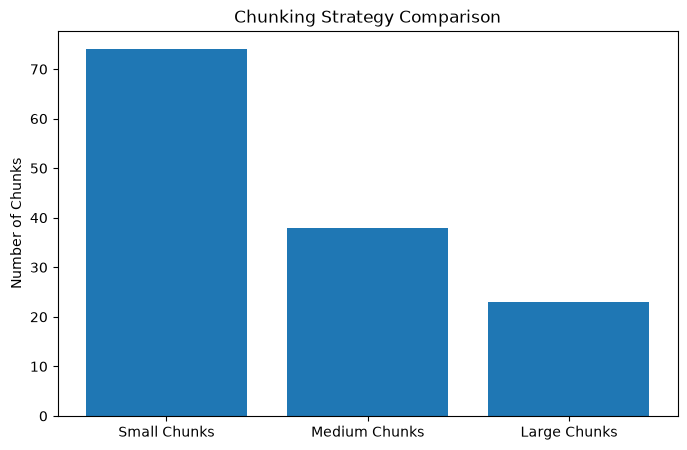

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Strategy"],
    comparison["Number of Chunks"]
)

plt.ylabel("Number of Chunks")
plt.title("Chunking Strategy Comparison")

plt.show()

## Analysis

The chunking strategy significantly affected document retrieval.

### Small Chunks (500)

- Produced more chunks.
- Higher retrieval precision.
- Better for specific questions.

### Medium Chunks (1000)

- Balanced context and retrieval.
- Provided consistent answers.
- Suitable for most RAG systems.

### Large Chunks (1500)

- Produced fewer chunks.
- Preserved more context.
- May retrieve unnecessary information.

The medium chunk size provided the best balance between retrieval accuracy and contextual understanding.

## Conclusion

Chunk size directly impacts retrieval performance in RAG systems.

Smaller chunks improve precision, while larger chunks preserve more context.

The medium chunking strategy achieved the best balance between retrieval accuracy and contextual completeness.

This experiment demonstrates the importance of selecting an appropriate chunk size for Retrieval-Augmented Generation applications.